# Notebook 05: Kunden-Clustering und Segmentierung

Dieser Abschnitt untersucht, wie Kunden anhand gemeinsamer Merkmale in sinnvolle Gruppen eingeteilt werden können. Ziel ist es, unterschiedliche Kundentypen zu identifizieren und Muster zu erkennen, die für Marketing, Produktstrategie und Kundenmanagement relevant sind.

## Ziel der Analyse
- Identifikation homogener Kundensegmente
- Erkennung von Gemeinsamkeiten und Unterschieden zwischen Kundengruppen
- Ableitung von Handlungsempfehlungen für gezielte Kampagnen und Strategien
- Bewertung der Stabilität und Qualität der Clusterbildung

## Datengrundlage
Der analysierte Datensatz enthält kundenspezifische Merkmale, die vor der Clusterbildung standardisiert werden, damit Unterschiede in den Skalenniveaus nicht verzerrt werden. Anschließend werden die Merkmale für die Clusteranalyse aufbereitet.

## Methodik
- Datenbereinigung und Feature-Auswahl
- Standardisierung der Kennzahlen
- Anwendung eines Clustering-Verfahrens zur Gruppierung ähnlicher Kunden
- Analyse der Clusterprofile und Interpretation der Ergebnisse
- Identifikation von Subclustern bzw. engeren Kundengruppen innerhalb größerer Segmente
- Export der finalen Kundendaten mit Cluster- und Subcluster-Zuordnung

## Erwartete Ergebnisse
- Aufteilung der Kunden in klar voneinander abgegrenzte Segmente
- Verständnis darüber, welche Kundengruppen ähnliche Verhaltens- oder Merkmalsmuster aufweisen
- Grundlage für weiterführende Analysen, z. B. gezielte Kundenansprache oder Portfolio-Optimierung

## Abschluss
Die Ergebnisse liefern eine strukturierte Grundlage für die Interpretation von Kundengruppen und unterstützen spätere Entscheidungen im Bereich Customer Analytics, Marketing und Produktstrategie.

In [18]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [19]:
df_master_group = pd.read_csv("../data/preprocessed/master_group.csv")

In [20]:
df_master_group.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'total_sessions', 'total_trips',
       'flight_booked_cnt', 'flight_booked_valid_cnt', 'hotel_booked_cnt',
       'hotel_booked_valid_cnt', 'total_flights_cost', 'total_hotels_cost',
       'avg_checked_bags', 'avg_hotel_nights', 'discount_flight_uses',
       'discount_hotel_uses', 'total_cancellations', 'cancellation_rate',
       'buchung_ratio', 'total_spend', 'is_top_10_percent', 'group'],
      dtype='str')

In [21]:
# Nur Kunden aus der Gruppe 'Standard Kunde' filtern
df_standard = df_master_group[df_master_group["group"] == "Standard Kunde"].copy()

# ODER falls du den Namen df_master_group verwenden möchtest:
# df_master_group = df_master_group[df_master_group["group"] == "Standard Kunde"].copy()

# Überprüfung der Datensatzgröße
print(f"Anzahl gefilterter Kunden: {len(df_standard)}")
print(f"Form des neuen DataFrames: {df_standard.shape}")

Anzahl gefilterter Kunden: 2070
Form des neuen DataFrames: (2070, 26)


In [22]:
df_standard["gender"].value_counts()

gender
F    1809
M     256
O       5
Name: count, dtype: int64

In [23]:
# Mapping-Dictionary definieren
gender_map = {"F": 0, "M": 1, "O": 3}

# Mapping in df_standard anwenden
df_standard["gender"] = df_standard["gender"].map(gender_map)

# Überprüfung der Verteilung
print(df_standard["gender"].value_counts(dropna=False))

gender
0    1809
1     256
3       5
Name: count, dtype: int64


In [24]:
df_standard.drop(["group", "is_top_10_percent","home_airport","home_country","home_city"] , axis=1, inplace=True)

In [25]:
df_standard

,user_id,gender,married,has_children,age,total_sessions,total_trips,flight_booked_cnt,flight_booked_valid_cnt,hotel_booked_cnt,...,total_flights_cost,total_hotels_cost,avg_checked_bags,avg_hotel_nights,discount_flight_uses,discount_hotel_uses,total_cancellations,cancellation_rate,buchung_ratio,total_spend
6,167852,0,False,False,20,13,1,0,0,0,...,0.00,0.0,0.00,0.0,3,4,0,0.00,0.076923,0.00
12,228195,0,False,True,29,11,2,2,1,1,...,638.32,0.0,2.00,0.0,2,1,1,0.09,0.181818,638.32
19,306165,0,False,False,23,11,1,0,0,0,...,0.00,0.0,0.00,0.0,1,1,0,0.00,0.090909,0.00
23,330893,0,True,True,45,11,4,3,3,3,...,861.61,750.0,0.67,2.0,0,2,0,0.00,0.363636,1611.61
24,337227,0,True,False,37,10,2,1,1,1,...,44.78,470.0,1.00,10.0,0,1,0,0.00,0.200000,514.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5776,777366,0,False,False,51,8,2,1,1,1,...,108.73,628.0,0.00,2.0,1,0,0,0.00,0.250000,736.73
5777,780167,0,True,True,52,8,3,2,2,1,...,1122.11,220.0,0.00,1.0,2,1,0,0.00,0.375000,1342.11
5778,785186,0,True,True,47,8,3,2,2,2,...,353.35,184.0,0.00,0.5,1,2,0,0.00,0.375000,537.35
5780,811077,0,True,True,47,8,2,1,1,1,...,579.79,852.0,0.00,6.0,2,1,0,0.00,0.250000,1431.79


In [26]:
X = df_standard.copy()

In [27]:
X.info()

<class 'pandas.DataFrame'>
Index: 2070 entries, 6 to 5781
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  2070 non-null   int64  
 1   gender                   2070 non-null   int64  
 2   married                  2070 non-null   bool   
 3   has_children             2070 non-null   bool   
 4   age                      2070 non-null   int64  
 5   total_sessions           2070 non-null   int64  
 6   total_trips              2070 non-null   int64  
 7   flight_booked_cnt        2070 non-null   int64  
 8   flight_booked_valid_cnt  2070 non-null   int64  
 9   hotel_booked_cnt         2070 non-null   int64  
 10  hotel_booked_valid_cnt   2070 non-null   int64  
 11  total_flights_cost       2070 non-null   float64
 12  total_hotels_cost        2070 non-null   float64
 13  avg_checked_bags         2070 non-null   float64
 14  avg_hotel_nights         2070 non-null  

In [28]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

In [29]:
X_scaled = pd.DataFrame(
    X_scaled_array,  index=X.index)

In [30]:
X_scaled

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
6,-6.767981,-0.36554,-0.823913,-0.782400,-1.775196,7.251763,-1.669155,-1.395715,-1.411732,-1.506004,...,-1.290943,-1.132445,-0.873478,-1.030182,1.414785,2.946060,-0.226657,-0.226843,-2.016154,-1.456420
12,-5.722160,-0.36554,-0.823913,1.278119,-0.976300,4.159868,-0.660352,0.511301,-0.412660,-0.505867,...,0.502592,-1.132445,3.190901,-1.030182,0.496727,-0.127702,4.241726,3.223022,-1.148542,-0.600432
19,-4.370840,-0.36554,-0.823913,-0.782400,-1.508897,4.159868,-1.669155,-1.395715,-1.411732,-1.506004,...,-1.290943,-1.132445,-0.873478,-1.030182,-0.421331,-0.127702,-0.226657,-0.226843,-1.900472,-1.456420
23,-3.942272,-0.36554,1.213721,1.278119,0.443960,4.159868,1.357254,1.464810,1.585484,1.494409,...,1.129986,0.222972,0.488089,-0.199503,-1.339389,0.896885,-0.226657,-0.226843,0.355318,0.704751
24,-3.832496,-0.36554,1.213721,-0.782400,-0.266170,2.613921,-0.660352,-0.442207,-0.412660,-0.505867,...,-1.165122,-0.283051,1.158711,3.123212,-1.339389,-0.127702,-0.226657,-0.226843,-0.998156,-0.766100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5776,3.795676,-0.36554,-0.823913,-0.782400,0.976557,-0.477974,-0.660352,-0.442207,-0.412660,-0.505867,...,-0.985437,0.002490,-0.873478,-0.199503,-0.421331,-1.152289,-0.226657,-0.226843,-0.584594,-0.468464
5777,3.844221,-0.36554,1.213721,1.278119,1.065323,-0.477974,0.348451,0.511301,0.586412,-0.505867,...,1.861933,-0.734856,-0.873478,-0.614843,0.496727,-0.127702,-0.226657,-0.226843,0.449309,0.343351
5778,3.931206,-0.36554,1.213721,1.278119,0.621492,-0.477974,0.348451,0.511301,0.586412,0.494271,...,-0.298110,-0.799916,-0.873478,-0.822513,-0.421331,0.896885,-0.226657,-0.226843,0.449309,-0.735833
5780,4.379931,-0.36554,1.213721,1.278119,0.621492,-0.477974,-0.660352,-0.442207,-0.412660,-0.505867,...,0.338136,0.407308,-0.873478,1.461854,0.496727,-0.127702,-0.226657,-0.226843,-0.584594,0.463612


In [31]:
X_scaled.to_csv("../data/scaled/user_features_scaled.csv", index=False)

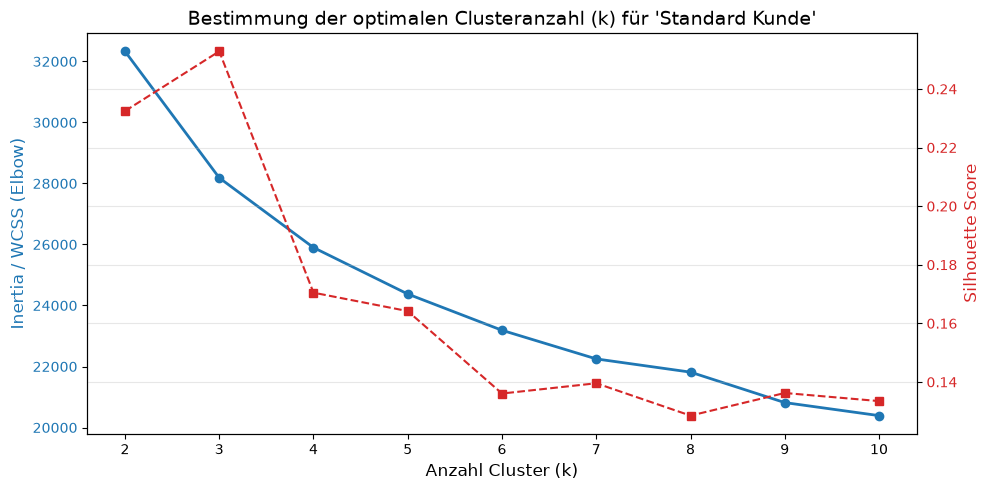

In [32]:


# 1. Inertia (Elbow) und Silhouette-Scores berechnen
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, kmeans.labels_)
    )

# 2. Elbow- und Silhouette-Plot erstellen
fig, ax1 = plt.subplots(figsize=(10, 5))

# Linke Y-Achse: WCSS / Inertia (Elbow)
color = "tab:blue"
ax1.set_xlabel("Anzahl Cluster (k)", fontsize=12)
ax1.set_ylabel("Inertia / WCSS (Elbow)", color=color, fontsize=12)
ax1.plot(k_range, inertia, marker="o", color=color, linewidth=2, label="Inertia")
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xticks(list(k_range))

# Rechte Y-Achse: Silhouette Score
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Silhouette Score", color=color, fontsize=12)
ax2.plot(
    k_range,
    silhouette_scores,
    marker="s",
    linestyle="--",
    color=color,
    label="Silhouette Score",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Bestimmung der optimalen Clusteranzahl (k) für 'Standard Kunde'",
    fontsize=14,
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../report/elbow_silhouette_plot.png", dpi=300) 
plt.show()

In [33]:
from sklearn.cluster import KMeans

# 1. K-Means Modell mit k=3 trainieren
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_standard["sub_cluster"] = kmeans.fit_predict(X_scaled)

# 2. Verteilung der Kunden auf die 3 Sub-Cluster prüfen
print("Verteilung der Kunden auf die Sub-Cluster:")
print(df_standard["sub_cluster"].value_counts())
print("\n" + "=" * 50 + "\n")

# 3. Profiling: Mittelwerte der wichtigsten Metriken pro Sub-Cluster vergleichen
profile_cols = [
    "age",
    "total_sessions",
    "total_trips",
    "total_flights_cost",
    "total_hotels_cost",
    "total_spend",
    "cancellation_rate",
    "buchung_ratio",
    "discount_flight_uses",
    "discount_hotel_uses",
]

cluster_profile = (
    df_standard.groupby("sub_cluster")[profile_cols].mean().round(2)
)
display(cluster_profile)

Verteilung der Kunden auf die Sub-Cluster:
sub_cluster
0    1092
1     875
2     103
Name: count, dtype: int64




,age,total_sessions,total_trips,total_flights_cost,total_hotels_cost,total_spend,cancellation_rate,buchung_ratio,discount_flight_uses,discount_hotel_uses
sub_cluster,,,,,,,,,,
0,43.73,8.34,3.39,663.51,881.69,1545.21,0.00,0.41,1.43,1.10
1,35.60,8.27,1.69,177.23,294.38,471.62,0.00,0.21,1.39,1.05
2,37.78,8.32,3.10,693.43,744.79,1438.21,0.12,0.37,2.36,2.00


In [34]:
cluster_profile.to_csv("../data/cluster/cluster_profile.csv", index=False)

In [35]:
# 1. Aussagekräftige Namen für die Sub-Cluster definieren
cluster_names = {
    0: "Standard - Treue Wertkäufer",
    1: "Standard - Low-Engagement Surfer",
    2: "Standard - Deal-Seeker & Storno-Risiko",
}

# 2. Bezeichnungen in df_standard eintragen
df_standard["sub_cluster_label"] = df_standard["sub_cluster"].map(
    cluster_names
)

# 3. Neue Gruppen-Labels in den Haupt-DataFrame df_master_group zurückschreiben
df_master_group.loc[df_standard.index, "group"] = df_standard["sub_cluster_label"]

# 4. Gesamte aktualisierte Segmentverteilung anzeigen
print("Neue finale Verteilung aller Kundensegmente in df_master_group:")
print(df_master_group["group"].value_counts())

Neue finale Verteilung aller Kundensegmente in df_master_group:
group
Top Spender Hotel                         1550
Top Spender Flug                          1096
Standard - Treue Wertkäufer               1092
Standard - Low-Engagement Surfer           875
Top Spender Allgemein                      579
Rentner (>60)                              251
Oft Bucher                                 200
Standard - Deal-Seeker & Storno-Risiko     103
Young (<20)                                 36
Name: count, dtype: int64


In [36]:
df_standard

,user_id,gender,married,has_children,age,total_sessions,total_trips,flight_booked_cnt,flight_booked_valid_cnt,hotel_booked_cnt,...,avg_checked_bags,avg_hotel_nights,discount_flight_uses,discount_hotel_uses,total_cancellations,cancellation_rate,buchung_ratio,total_spend,sub_cluster,sub_cluster_label
6,167852,0,False,False,20,13,1,0,0,0,...,0.00,0.0,3,4,0,0.00,0.076923,0.00,1,Standard - Low-Engagement Surfer
12,228195,0,False,True,29,11,2,2,1,1,...,2.00,0.0,2,1,1,0.09,0.181818,638.32,2,Standard - Deal-Seeker & Storno-Risiko
19,306165,0,False,False,23,11,1,0,0,0,...,0.00,0.0,1,1,0,0.00,0.090909,0.00,1,Standard - Low-Engagement Surfer
23,330893,0,True,True,45,11,4,3,3,3,...,0.67,2.0,0,2,0,0.00,0.363636,1611.61,0,Standard - Treue Wertkäufer
24,337227,0,True,False,37,10,2,1,1,1,...,1.00,10.0,0,1,0,0.00,0.200000,514.78,1,Standard - Low-Engagement Surfer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5776,777366,0,False,False,51,8,2,1,1,1,...,0.00,2.0,1,0,0,0.00,0.250000,736.73,1,Standard - Low-Engagement Surfer
5777,780167,0,True,True,52,8,3,2,2,1,...,0.00,1.0,2,1,0,0.00,0.375000,1342.11,0,Standard - Treue Wertkäufer
5778,785186,0,True,True,47,8,3,2,2,2,...,0.00,0.5,1,2,0,0.00,0.375000,537.35,0,Standard - Treue Wertkäufer
5780,811077,0,True,True,47,8,2,1,1,1,...,0.00,6.0,2,1,0,0.00,0.250000,1431.79,1,Standard - Low-Engagement Surfer


In [43]:
df_standard.to_csv("../data/cluster/standard_customers_with_subclusters.csv", index=False)

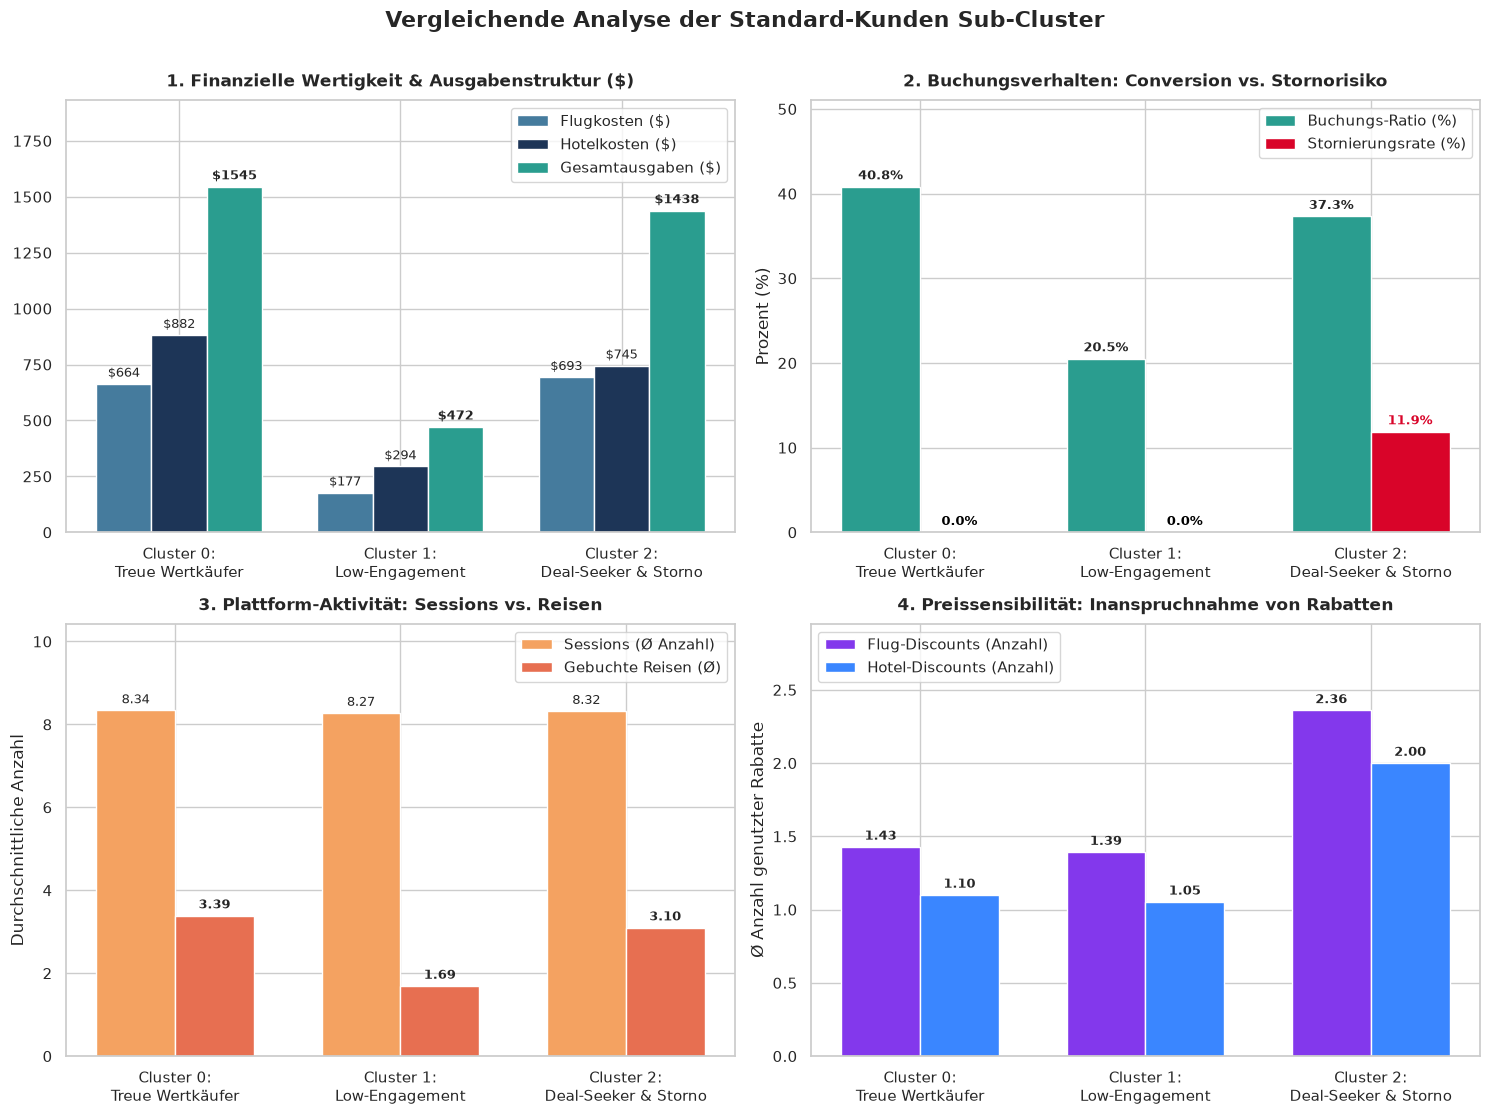

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. DATEN AGGREGIEREN (mit numeric_only=True)
# ---------------------------------------------------------
cluster_names = {
    0: "Cluster 0:\nTreue Wertkäufer",
    1: "Cluster 1:\nLow-Engagement",
    2: "Cluster 2:\nDeal-Seeker & Storno",
}

# WICHTIG: numeric_only=True ignoriert alle Textspalten
df_summary = (
    df_standard.groupby("sub_cluster").mean(numeric_only=True).reset_index()
)
df_summary["label"] = df_summary["sub_cluster"].map(cluster_names)

# ---------------------------------------------------------
# 2. DASHBOARD SETUP
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

x = np.arange(len(df_summary))
w_triple = 0.25
w_double = 0.35


# ---------------------------------------------------------
# CHART 1: FINANZIELLE WERTIGKEIT
# ---------------------------------------------------------
rects1 = axes[0, 0].bar(
    x - w_triple,
    df_summary["total_flights_cost"],
    w_triple,
    label="Flugkosten ($)",
    color="#457b9d",
)
rects2 = axes[0, 0].bar(
    x,
    df_summary["total_hotels_cost"],
    w_triple,
    label="Hotelkosten ($)",
    color="#1d3557",
)
rects3 = axes[0, 0].bar(
    x + w_triple,
    df_summary["total_spend"],
    w_triple,
    label="Gesamtausgaben ($)",
    color="#2a9d8f",
)

axes[0, 0].set_title(
    "1. Finanzielle Wertigkeit & Ausgabenstruktur ($)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(df_summary["label"])
axes[0, 0].set_ylim(0, max(df_summary["total_spend"]) * 1.25)
axes[0, 0].legend(loc="upper right", frameon=True)

for p in rects1:
    axes[0, 0].annotate(
        f"${p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9,
    )
for p in rects2:
    axes[0, 0].annotate(
        f"${p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9,
    )
for p in rects3:
    axes[0, 0].annotate(
        f"${p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
    )


# ---------------------------------------------------------
# CHART 2: BUCHUNGSVERHALTEN & STORNO
# ---------------------------------------------------------
rects_conv = axes[0, 1].bar(
    x - w_double / 2,
    df_summary["buchung_ratio"] * 100,
    w_double,
    label="Buchungs-Ratio (%)",
    color="#2a9d8f",
)
rects_storno = axes[0, 1].bar(
    x + w_double / 2,
    df_summary["cancellation_rate"] * 100,
    w_double,
    label="Stornierungsrate (%)",
    color="#d90429",
)

axes[0, 1].set_title(
    "2. Buchungsverhalten: Conversion vs. Stornorisiko",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(df_summary["label"])
axes[0, 1].set_ylabel("Prozent (%)")
axes[0, 1].set_ylim(0, max(df_summary["buchung_ratio"] * 100) * 1.25)
axes[0, 1].legend(loc="upper right", frameon=True)

for p in rects_conv:
    axes[0, 1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
    )
for p in rects_storno:
    val = p.get_height()
    axes[0, 1].annotate(
        f"{val:.1f}%",
        (p.get_x() + p.get_width() / 2.0, val),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
        color="#d90429" if val > 0 else "black",
    )


# ---------------------------------------------------------
# CHART 3: PLATTFORM-AKTIVITÄT
# ---------------------------------------------------------
rects_sess = axes[1, 0].bar(
    x - w_double / 2,
    df_summary["total_sessions"],
    w_double,
    label="Sessions (Ø Anzahl)",
    color="#f4a261",
)
rects_trips = axes[1, 0].bar(
    x + w_double / 2,
    df_summary["total_trips"],
    w_double,
    label="Gebuchte Reisen (Ø)",
    color="#e76f51",
)

axes[1, 0].set_title(
    "3. Plattform-Aktivität: Sessions vs. Reisen",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(df_summary["label"])
axes[1, 0].set_ylabel("Durchschnittliche Anzahl")
axes[1, 0].set_ylim(0, max(df_summary["total_sessions"]) * 1.25)
axes[1, 0].legend(loc="upper right", frameon=True)

for p in rects_sess:
    axes[1, 0].annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9,
    )
for p in rects_trips:
    axes[1, 0].annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
    )


# ---------------------------------------------------------
# CHART 4: PREISSENSIBILITÄT & RABATTE
# ---------------------------------------------------------
rects_disc_f = axes[1, 1].bar(
    x - w_double / 2,
    df_summary["discount_flight_uses"],
    w_double,
    label="Flug-Discounts (Anzahl)",
    color="#8338ec",
)
rects_disc_h = axes[1, 1].bar(
    x + w_double / 2,
    df_summary["discount_hotel_uses"],
    w_double,
    label="Hotel-Discounts (Anzahl)",
    color="#3a86ff",
)

axes[1, 1].set_title(
    "4. Preissensibilität: Inanspruchnahme von Rabatten",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(df_summary["label"])
axes[1, 1].set_ylabel("Ø Anzahl genutzter Rabatte")
axes[1, 1].set_ylim(0, max(df_summary["discount_flight_uses"]) * 1.25)
axes[1, 1].legend(loc="upper left", frameon=True)

for p in rects_disc_f:
    axes[1, 1].annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
    )
for p in rects_disc_h:
    axes[1, 1].annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
    )


plt.suptitle(
    "Vergleichende Analyse der Standard-Kunden Sub-Cluster",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("../report/cluster_dashboard.png", dpi=300)
plt.show()

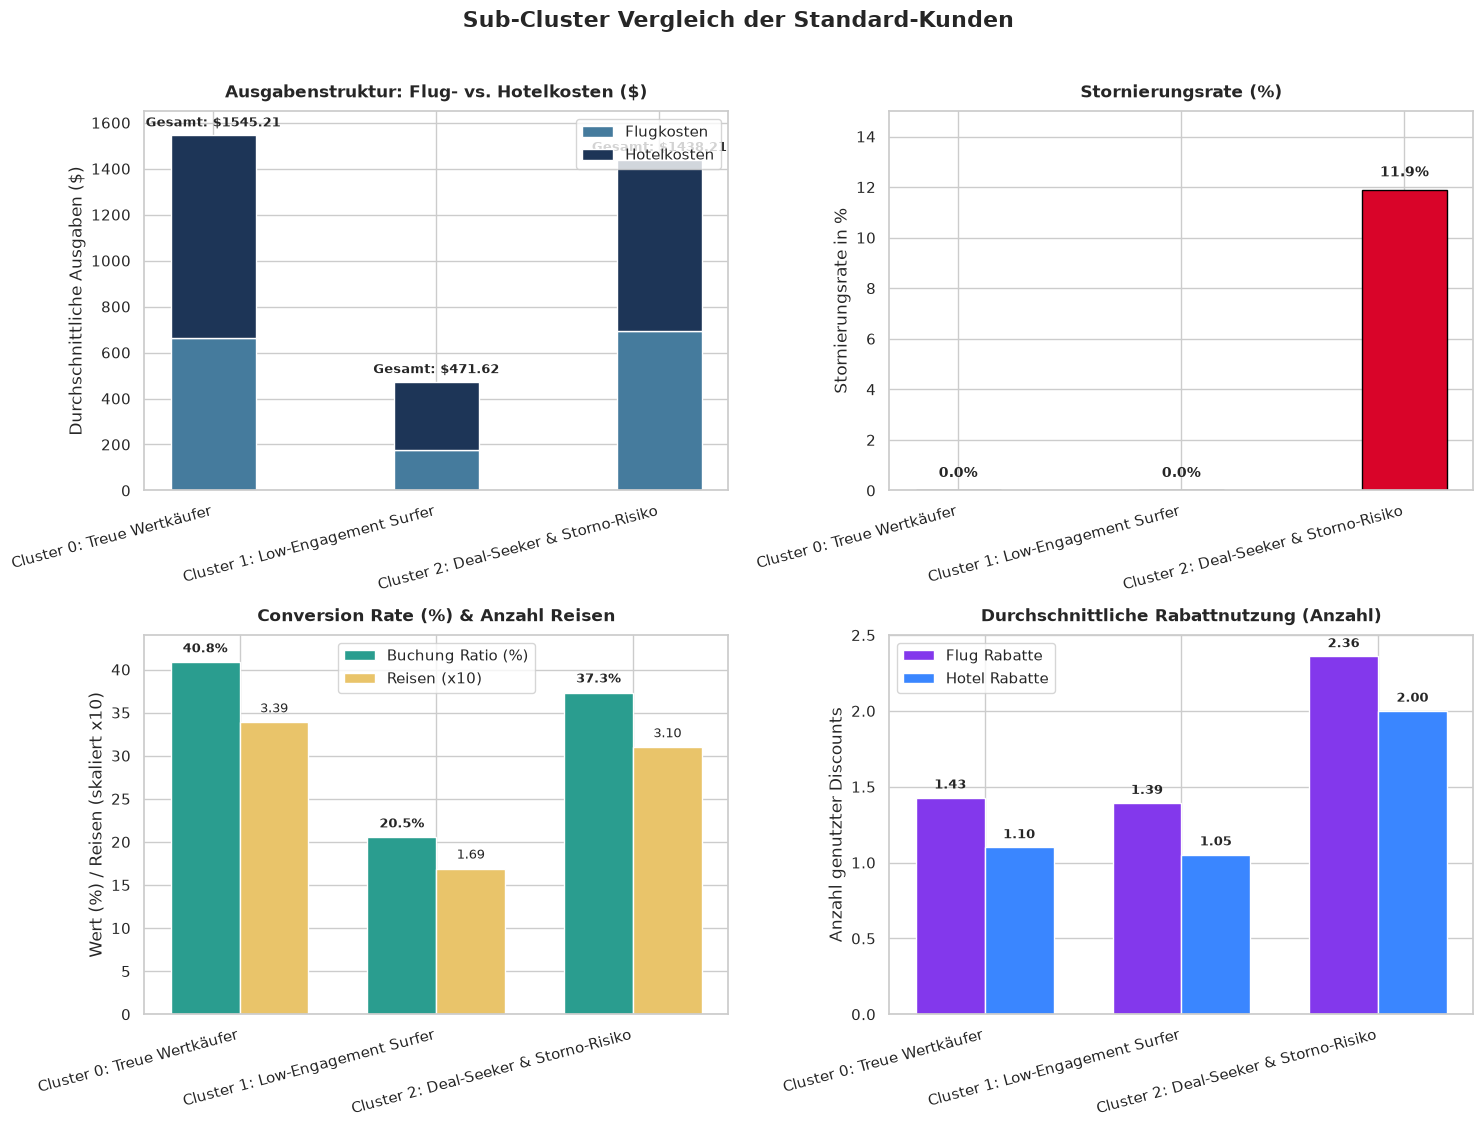

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. DATEN AGGREGIEREN & VORBEREITEN
# ---------------------------------------------------------
cluster_names = {
    0: "Cluster 0: Treue Wertkäufer",
    1: "Cluster 1: Low-Engagement Surfer",
    2: "Cluster 2: Deal-Seeker & Storno-Risiko",
}

# Mittelwerte pro Sub-Cluster berechnen (numeric_only=True vermeidet Typ-Fehler)
df_summary = (
    df_standard.groupby("sub_cluster").mean(numeric_only=True).reset_index()
)
df_summary["label"] = df_summary["sub_cluster"].map(cluster_names)

# ---------------------------------------------------------
# 2. DASHBOARD SETUP
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

x = np.arange(len(df_summary))
width_bar = 0.38


# ---------------------------------------------------------
# CHART 1: AUSGABENSTRUKTUR (STACKED BAR)
# ---------------------------------------------------------
axes[0, 0].bar(
    x,
    df_summary["total_flights_cost"],
    width_bar,
    label="Flugkosten",
    color="#457b9d",
)
axes[0, 0].bar(
    x,
    df_summary["total_hotels_cost"],
    width_bar,
    bottom=df_summary["total_flights_cost"],
    label="Hotelkosten",
    color="#1d3557",
)

axes[0, 0].set_title(
    "Ausgabenstruktur: Flug- vs. Hotelkosten ($)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(df_summary["label"], rotation=15, ha="right")
axes[0, 0].set_ylabel("Durchschnittliche Ausgaben ($)")
axes[0, 0].set_ylim(0, 1650)
axes[0, 0].legend(loc="upper right", frameon=True)

# Gesamtsummen-Beschriftung über den gestapelten Balken
for i, row in df_summary.iterrows():
    total = row["total_flights_cost"] + row["total_hotels_cost"]
    axes[0, 0].annotate(
        f"Gesamt: ${total:.2f}",
        (x[i], total + 25),
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
    )


# ---------------------------------------------------------
# CHART 2: STORNIERUNGSRATE (%)
# ---------------------------------------------------------
bars_storno = axes[0, 1].bar(
    x,
    df_summary["cancellation_rate"] * 100,
    width_bar,
    color="#d90429",
    edgecolor="black",
)

axes[0, 1].set_title(
    "Stornierungsrate (%)", fontsize=12, fontweight="bold", pad=10
)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(df_summary["label"], rotation=15, ha="right")
axes[0, 1].set_ylabel("Stornierungsrate in %")
axes[0, 1].set_ylim(0, 15)

for p in bars_storno:
    val = p.get_height()
    axes[0, 1].annotate(
        f"{val:.1f}%",
        (p.get_x() + p.get_width() / 2.0, val + 0.4),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )


# ---------------------------------------------------------
# CHART 3: CONVERSION RATE (%) & ANZAHL REISEN (SKALIERT x10)
# ---------------------------------------------------------
w_grouped = 0.35
rects_conv = axes[1, 0].bar(
    x - w_grouped / 2,
    df_summary["buchung_ratio"] * 100,
    w_grouped,
    label="Buchung Ratio (%)",
    color="#2a9d8f",
)
rects_trips = axes[1, 0].bar(
    x + w_grouped / 2,
    df_summary["total_trips"] * 10,
    w_grouped,
    label="Reisen (x10)",
    color="#e9c46a",
)

axes[1, 0].set_title(
    "Conversion Rate (%) & Anzahl Reisen",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(df_summary["label"], rotation=15, ha="right")
axes[1, 0].set_ylabel("Wert (%) / Reisen (skaliert x10)")
axes[1, 0].set_ylim(0, 44)
axes[1, 0].legend(loc="upper center", frameon=True)

for p in rects_conv:
    val = p.get_height()
    axes[1, 0].annotate(
        f"{val:.1f}%",
        (p.get_x() + p.get_width() / 2.0, val + 0.8),
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
    )
for i, p in enumerate(rects_trips):
    raw_trips = df_summary["total_trips"].iloc[i]
    val = p.get_height()
    axes[1, 0].annotate(
        f"{raw_trips:.2f}",
        (p.get_x() + p.get_width() / 2.0, val + 0.8),
        ha="center",
        va="bottom",
        fontsize=9.5,
    )


# ---------------------------------------------------------
# CHART 4: DURCHSCHNITTLICHE RABATTNUTZUNG
# ---------------------------------------------------------
rects_disc_f = axes[1, 1].bar(
    x - w_grouped / 2,
    df_summary["discount_flight_uses"],
    w_grouped,
    label="Flug Rabatte",
    color="#8338ec",
)
rects_disc_h = axes[1, 1].bar(
    x + w_grouped / 2,
    df_summary["discount_hotel_uses"],
    w_grouped,
    label="Hotel Rabatte",
    color="#3a86ff",
)

axes[1, 1].set_title(
    "Durchschnittliche Rabattnutzung (Anzahl)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(df_summary["label"], rotation=15, ha="right")
axes[1, 1].set_ylabel("Anzahl genutzter Discounts")
axes[1, 1].set_ylim(0, 2.5)
axes[1, 1].legend(loc="upper left", frameon=True)

for p in rects_disc_f:
    val = p.get_height()
    axes[1, 1].annotate(
        f"{val:.2f}",
        (p.get_x() + p.get_width() / 2.0, val + 0.04),
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
    )
for p in rects_disc_h:
    val = p.get_height()
    axes[1, 1].annotate(
        f"{val:.2f}",
        (p.get_x() + p.get_width() / 2.0, val + 0.04),
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
    )


# ---------------------------------------------------------
# DASHBOARD TITEL & LAYOUT
# ---------------------------------------------------------
plt.suptitle(
    "Sub-Cluster Vergleich der Standard-Kunden",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("../report/Sub-Cluster_Vergleich_dashboard.png", dpi=300)
plt.show()

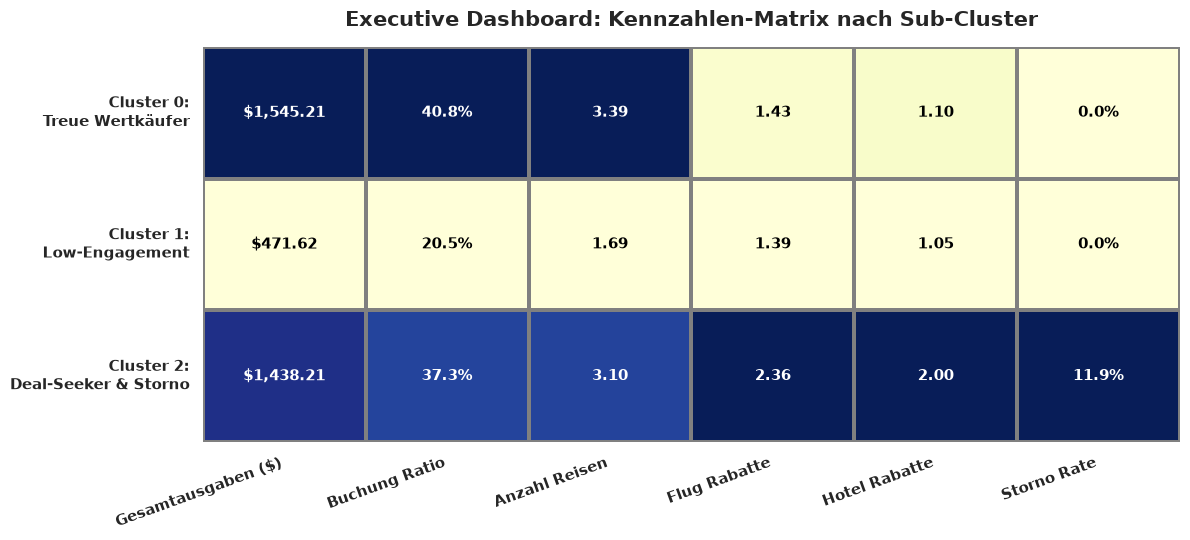

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. DATEN AGGREGIEREN & MATRIX VORBEREITEN
# ---------------------------------------------------------
# Falls aus dem Haupt-Dataframe 'df_standard' gelesen wird:
df_summary = (
    df_standard.groupby("sub_cluster").mean(numeric_only=True).reset_index()
)

# Relevante Spalten auswählen und umbenennen
metrics_df = pd.DataFrame(
    {
        "Gesamtausgaben ($)": df_summary["total_spend"],
        "Buchung Ratio": df_summary["buchung_ratio"],
        "Anzahl Reisen": df_summary["total_trips"],
        "Flug Rabatte": df_summary["discount_flight_uses"],
        "Hotel Rabatte": df_summary["discount_hotel_uses"],
        "Storno Rate": df_summary["cancellation_rate"],
    }
)

cluster_labels = [
    "Cluster 0:\nTreue Wertkäufer",
    "Cluster 1:\nLow-Engagement",
    "Cluster 2:\nDeal-Seeker & Storno",
]

# Spaltenweise Normalisierung (Min-Max) für die Farbintensität
df_norm = (metrics_df - metrics_df.min()) / (
    metrics_df.max() - metrics_df.min()
)
df_norm = df_norm.fillna(0)  # Verhindert NaN bei 0-Varianz

# Formatierte Text-Labels erstellen
formatted_text = np.empty(metrics_df.shape, dtype=object)
for i in range(metrics_df.shape[0]):
    for j in range(metrics_df.shape[1]):
        col_name = metrics_df.columns[j]
        val = metrics_df.iloc[i, j]
        if "Gesamtausgaben" in col_name:
            formatted_text[i, j] = f"${val:,.2f}"
        elif "Ratio" in col_name or "Rate" in col_name:
            formatted_text[i, j] = f"{val*100:.1f}%"
        else:
            formatted_text[i, j] = f"{val:.2f}"

# ---------------------------------------------------------
# 2. HEATMAP PLOTTEN
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5.5))

sns.heatmap(
    df_norm,
    annot=formatted_text,
    fmt="",
    cmap="YlGnBu",
    cbar=False,
    linewidths=1.5,
    linecolor="grey",
    yticklabels=cluster_labels,
    xticklabels=metrics_df.columns,
    ax=ax,
    annot_kws={"size": 11, "weight": "bold"},
)

# Dynamische Textfarbe (Weiß bei dunklem Hintergrund, Schwarz bei hellem)
for text, val_norm in zip(ax.texts, df_norm.values.flatten()):
    text.set_color("white" if val_norm > 0.5 else "black")

ax.set_title(
    "Executive Dashboard: Kennzahlen-Matrix nach Sub-Cluster",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=20, ha="right", fontweight="bold", fontsize=11)
plt.yticks(rotation=0, fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("../report/cluster_metrics_heatmap.png", dpi=300)
plt.show()

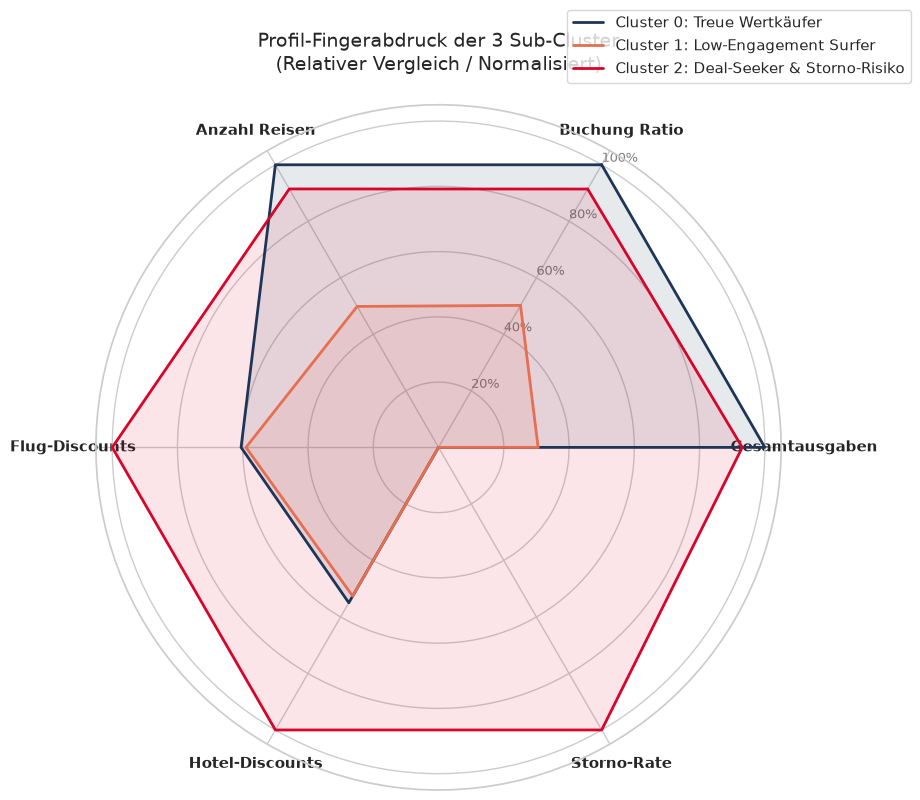

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. DATEN FÜR RADAR CHART NORMALISIEREN
# ---------------------------------------------------------
categories = [
    "Buchung Ratio",
    "Gesamtausgaben",
    "Storno-Rate",
    "Hotel-Discounts",
    "Flug-Discounts",
    "Anzahl Reisen",
]
N = len(categories)

# Erstellen der Datenmatrix
radar_data = {
    "Cluster 0: Treue Wertkäufer": [
        df_summary["buchung_ratio"].iloc[0],
        df_summary["total_spend"].iloc[0],
        df_summary["cancellation_rate"].iloc[0],
        df_summary["discount_hotel_uses"].iloc[0],
        df_summary["discount_flight_uses"].iloc[0],
        df_summary["total_trips"].iloc[0],
    ],
    "Cluster 1: Low-Engagement Surfer": [
        df_summary["buchung_ratio"].iloc[1],
        df_summary["total_spend"].iloc[1],
        df_summary["cancellation_rate"].iloc[1],
        df_summary["discount_hotel_uses"].iloc[1],
        df_summary["discount_flight_uses"].iloc[1],
        df_summary["total_trips"].iloc[1],
    ],
    "Cluster 2: Deal-Seeker & Storno-Risiko": [
        df_summary["buchung_ratio"].iloc[2],
        df_summary["total_spend"].iloc[2],
        df_summary["cancellation_rate"].iloc[2],
        df_summary["discount_hotel_uses"].iloc[2],
        df_summary["discount_flight_uses"].iloc[2],
        df_summary["total_trips"].iloc[2],
    ],
}

df_radar = pd.DataFrame(radar_data, index=categories)

# Normalisierung relativ zum Maximalwert jeder Kennzahl (0% bis 100%)
df_radar_max = df_radar.max(axis=1)
df_radar_norm = df_radar.div(df_radar_max, axis=0).fillna(0)

# ---------------------------------------------------------
# 2. RADAR CHART PLOTTEN
# ---------------------------------------------------------
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Kreis schließen

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(polar=True))

# Ausrichtung: Start oben rechts, Uhrzeigersinn
ax.set_theta_offset(np.pi / 3)
ax.set_theta_direction(-1)

# Achsenbeschriftungen
plt.xticks(angles[:-1], categories, size=11, fontweight="bold")
ax.set_rlabel_position(0)
plt.yticks(
    [0.2, 0.4, 0.6, 0.8, 1.0],
    ["20%", "40%", "60%", "80%", "100%"],
    color="grey",
    size=9,
)
plt.ylim(0, 1.05)

# Farben definieren
colors = {
    "Cluster 0: Treue Wertkäufer": "#1d3557",
    "Cluster 1: Low-Engagement Surfer": "#e76f51",
    "Cluster 2: Deal-Seeker & Storno-Risiko": "#d90429",
}

# Cluster-Kurven zeichnen
for col in df_radar_norm.columns:
    values = df_radar_norm[col].values.flatten().tolist()
    values += values[:1]
    ax.plot(
        angles,
        values,
        linewidth=2,
        linestyle="solid",
        label=col,
        color=colors[col],
    )
    ax.fill(angles, values, color=colors[col], alpha=0.1)

plt.title(
    "Profil-Fingerabdruck der 3 Sub-Cluster\n(Relativer Vergleich / Normalisiert)",
    fontsize=14,
    pad=25,
)
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.15), frameon=True)

plt.tight_layout()
plt.savefig("../report/cluster_radar_chart.png", dpi=300)
plt.show()

# Analyse der Sub-Cluster: Standard-Kunden

Hier ist die detaillierte Auswertung und Interpretation der drei identifizierten Sub-Cluster innerhalb der **„Standard Kunden“**.

## 1. Charakterisierung & Personas der 3 Sub-Cluster

### Sub-Cluster 0: „Standard – Treue Wertkäufer“ (Organische Premium-Kunden)

* **Profil:** Älteres Kundensegment (Ø 43,7 Jahre) mit dem **höchsten Gesamtausgabe-Niveau ($1.545,21)** und der **höchsten Buchungsquote (41 %)**.
* **Besonderheiten:** Buchen häufig (Ø 3,39 Trips), weisen eine **Stornierungsrate von 0,00 %** auf und nutzen vergleichsweise wenig Rabatte (Ø 1,43 Flug- / 1,10 Hotel-Discounts).
* **Bedeutung:** Das stabilste und profitabelste Segment unter den Standard-Kunden.

### Sub-Cluster 1: „Standard – Low-Engagement Surfer“ (Budget- / Gelegenheitsnutzer)

* **Profil:** Jüngeres Segment (Ø 35,6 Jahre) mit **sehr geringem Umsatz ($471,62)** und wenigen Reisen (Ø 1,69 Trips).
* **Besonderheiten:** Trotz vergleichbar hoher Aktivität auf der Plattform (Ø 8,27 Sessions) ist die **Conversion-Rate sehr niedrig (21 %)**.
* **Bedeutung:** Starke Stöber-Aktivität (Browsing), aber eine hohe Hürde beim finalen Kaufabschluss.

### Sub-Cluster 2: „Standard – Deal-Seeker mit Storno-Risiko“

* **Profil:** Mittleres Alter (Ø 37,8 Jahre) mit hohem Umsatz ($1.438,21) und hoher Reisetätigkeit (Ø 3,10 Trips).
* **Besonderheiten:** Extrem **hohe Rabattnutzung** (Ø 2,36 Flug- und 2,00 Hotel-Discounts), gepaart mit einer **Stornierungsrate von 12,0 %** (das einzige Cluster mit Stornierungen).
* **Bedeutung:** Reagiert stark auf Promotionen, neigt aber auch zu flexiblen bzw. spontanen Stornierungen.

---

## 2. Kennzahlen-Übersicht im Vergleich

| Kennzahl                                   | Sub-Cluster 0 (Treue Wertkäufer) | Sub-Cluster 1 (Low-Engagement) | Sub-Cluster 2 (Deal-Seeker) |
| :----------------------------------------- | :------------------------------: | :----------------------------: | :-------------------------: |
| **Alter (Ø)**                              |            **43,7 J.**           |             35,6 J.            |           37,8 J.           |
| **Gesamtausgaben (`total_spend`)**         |           **$1.545,21**          |             $471,62            |          $1.438,21          |
| **Flugkosten (`total_flights_cost`)**      |              $663,51             |             $177,23            |         **$693,43**         |
| **Hotelkosten (`total_hotels_cost`)**      |            **$881,69**           |             $294,38            |           $744,79           |
| **Anzahl Reisen (`total_trips`)**          |             **3,39**             |              1,69              |             3,10            |
| **Conversion (`buchung_ratio`)**           |             **41 %**             |              21 %              |             37 %            |
| **Stornierungsrate (`cancellation_rate`)** |             **0,0 %**            |            **0,0 %**           |          **12,0 %**         |
| **Rabatt-Nutzung Flug (Ø)**                |               1,43               |         Nicht angegeben        |             2,36            |
| **Rabatt-Nutzung Hotel (Ø)**               |               1,10               |         Nicht angegeben        |             2,00            |

---

## 3. Zusammenfassende Interpretation

| Sub-Cluster   | Zentrale Eigenschaft    | Auffälligkeit                                                                               |
| :------------ | :---------------------- | :------------------------------------------------------------------------------------------ |
| **Cluster 0** | Hohe Kundenbindung      | Höchste Ausgaben und Conversion bei keiner erfassten Stornierung                            |
| **Cluster 1** | Geringes Kaufengagement | Viele Plattform-Sessions, aber niedrige Conversion und geringe Ausgaben                     |
| **Cluster 2** | Hohe Preissensibilität  | Hohe Ausgaben und Reisetätigkeit bei intensiver Rabattnutzung und erhöhter Stornierungsrate |

**Hinweis:** Nicht angegebene Rabattwerte für Sub-Cluster 1 wurden bewusst als „Nicht angegeben“ markiert und nicht geschätzt.


# Marketing-Strategie & Maßnahmenempfehlungen: Sub-Cluster Analyse

**An:** Marketing-Team  
**Von:** Analytics & Data Team  
**Betreff:** Empfehlungen und Maßnahmenplan basierend auf der Sub-Cluster-Analyse der Standard-Kunden  

---

## 1. Executive Summary & IST-Zustand

Aus der datengestützten Analyse unserer Standard-Kunden haben sich drei klar abgegrenzte Sub-Cluster mit unterschiedlichem Buchungsverhalten, Rabattnutzung und Stornorisiko ergeben[cite: 10, 11]:

| Kennzahl | Cluster 0: Treue Wertkäufer | Cluster 1: Low-Engagement Surfer | Cluster 2: Deal-Seeker & Storno-Risiko |
| :--- | :--- | :--- | :--- |
| **Gesamtausgaben ($)** | **$1,545.21** *(Höchster Wert)* | $471.62 *(Niedrigster Wert)* | $1,438.21 *(Hoher Wert)* |
| **Conversion Rate (%)** | **41.0%**[cite: 10] | 21.0%[cite: 10] | 37.0%[cite: 10] |
| **Anzahl Reisen** | **3.39**[cite: 10] | 1.69[cite: 10] | 3.10[cite: 10] |
| **Flug- / Hotel-Rabatte** | 1.43 / 1.10 *(Gering)*[cite: 10] | 1.39 / 1.05 *(Gering)*[cite: 10] | **2.36 / 2.00** *(Exzessiv)*[cite: 10] |
| **Stornierungsrate (%)** | **0.0%**[cite: 10] | **0.0%**[cite: 10] | **12.0%** *(Kritisch)*[cite: 10] |

---

## 2. Clusterspezifische Maßnahmenempfehlungen

### Cluster 0: Treue Wertkäufer (Loyal High-Value)
* **Ziel:** Kundenbindung maximieren, Customer Lifetime Value (CLV) steigern und Margen schützen.
* **Strategie:** Dieser Kunde bucht häufig (3.39 Reisen)[cite: 10] und verlässlich (0.0% Storno)[cite: 10] – auch ohne starke Preisanreize[cite: 10]. Exzessive Rabattierung muss vermieden werden, um die Marge nicht unnötig zu schmälern.

* **Konkrete Marketing-Maßnahmen:**
  1. **Value-Add statt Preisnachlass:** Fokus auf exklusive Perks wie kostenlose Zimmer-Upgrades, Priority Check-in oder flexibles Gepäck statt prozentualer Rabatte.
  2. **VIP- / Loyalty-Programm:** Aufbau eines Premium-Status mit personalisierten Angeboten für Vielreisende.
  3. **Cross-Selling & Paket-Angebote:** Gezieltes Bündeln von Premium-Flügen mit 4- und 5-Sterne-Hotels zur Steigerung des Warenkorbs.

---

### Cluster 1: Low-Engagement Surfer
* **Ziel:** Conversion Rate aktivieren und Frequenz von Webseiten-Besuchen zu Buchungen erhöhen.
* **Strategie:** Hohes Suchvolumen, aber niedrige Buchungsquote (21.0%)[cite: 10]. Das Hauptproblem ist Unentschlossenheit oder fehlende Hürdenreduktion im Buchungsprozess.

* **Konkrete Marketing-Maßnahmen:**
  1. **Aktivierungs-Campaigns (First-Booking Incentive):** Zeitlich begrenzte Einstiegs-Gutscheine für die erste Buchung setzen, um die Kaufhürde zu senken.
  2. **Automatisierte Abandoned-Search E-Mails:** Trigger-Mails bei abgebrochenen Suchen mit Preisalarmen ("Flug nach X ist jetzt 10% günstiger") versenden.
  3. **Nudge Marketing & Urgency:** Einbinden von Social-Proof-Elementen in der Search-UI (z.B. "Nur noch 2 Zimmer zu diesem Preis verfügbar").

---

### Cluster 2: Deal-Seeker & Storno-Risiko
* **Ziel:** Rabatteffizienz optimieren, Stornorate senken und Marge absichern.
* **Strategie:** Dieser Kunde generiert zwar Umsatz ($1,438.21)[cite: 10], nutzt aber extrem viele Rabatte (im Schnitt 4.36 Rabatte pro Reise)[cite: 10] und weist eine sehr hohe Stornorate von 12.0% auf[cite: 10].

* **Konkrete Marketing-Maßnahmen:**
  1. **Kopplung von Rabatten an Nicht-Erstattungsfähige Tarife (Non-Refundable):** Hohe Rabatte (Flug & Hotel) nur noch bei Tarifen ohne kostenlose Stornierung gewähren.
  2. **Rabatt-Schwellenwerte einführen:** Mindestbestellwerte (Minimum Spend) für den Einsatz von Hotel- und Flug-Discounts durchsetzen.
  3. **Retargeting nach Stornierung:** Automatisierte Nachfass-Aktionen nach einer Stornierung anbieten, um direkt eine Umbuchung mit Verbindlichkeit zu fördern.

---

## 3. Implementierungs-Roadmap & Key Performance Indicators (KPIs)

```text
[Phase 1: Sofortmaßnahmen]  --->  [Phase 2: Kampagnen-Steuerung]  --->  [Phase 3: Systemische Anpassung]
• Stornogebundenheit bei           • Segmentierte Newsletter-          • Implementierung eines dynamischen
  Rabatten in Cluster 2               Verteiler aufbauen (Cl. 0-2)        Loyalty-Systems für Cluster 0
  einführen